In [1]:
import scanpy as sc
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import matplotlib.cm as cm
import seaborn as sb
from os import mkdir
import os
import warnings
import squarify
import matplotlib as mpl
import seaborn as sns

sc.set_figure_params(dpi=60, 
                     dpi_save=300, 
                     color_map= 'viridis_r',transparent=True,
                     frameon=True, vector_friendly=False, fontsize=14,
                     format='pdf')

plt.rcParams['figure.figsize']=(6,6) #rescale figures
plt.rcParams['grid.alpha']=0
sc.settings.verbosity = 3
#sc.logging.print_header()

In [2]:
adata= sc.read ('../cell_annotation_brain_NBs_1_Drosophila_and_Tribolium_label_transfer.h5ad')
#Core genes from all pathways downloaded from flybase
df = pd.read_csv("1_ALL_genes_with_pathways.csv")

In [3]:
remove_labels = [
    "plasmatocytes/embryonic hemocytes/macrophages",
    "Mesodermal/muscle progenitors",
    "PCGs"
]

adata = adata[~adata.obs["X_scVI_harmony_predicted"].isin(remove_labels)].copy()

computing score 'ACTIVIN'
    finished: added
    'ACTIVIN', score of gene set (adata.obs).
    200 total control genes are used. (0:00:00)
computing score 'BMP'
    finished: added
    'BMP', score of gene set (adata.obs).
    348 total control genes are used. (0:00:00)
computing score 'CGAS-STING'
    finished: added
    'CGAS-STING', score of gene set (adata.obs).
    50 total control genes are used. (0:00:00)
computing score 'EGFR'
    finished: added
    'EGFR', score of gene set (adata.obs).
    643 total control genes are used. (0:00:00)
computing score 'FGFR'
    finished: added
    'FGFR', score of gene set (adata.obs).
    596 total control genes are used. (0:00:00)
computing score 'HEDGEHOG'
    finished: added
    'HEDGEHOG', score of gene set (adata.obs).
    200 total control genes are used. (0:00:00)
computing score 'HIPPO'
    finished: added
    'HIPPO', score of gene set (adata.obs).
    250 total control genes are used. (0:00:00)
computing score 'IMD'
    finished: a

/tmp/ipykernel_114021/3691084236.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("X_scVI_harmony_predicted")[pathway_cols]


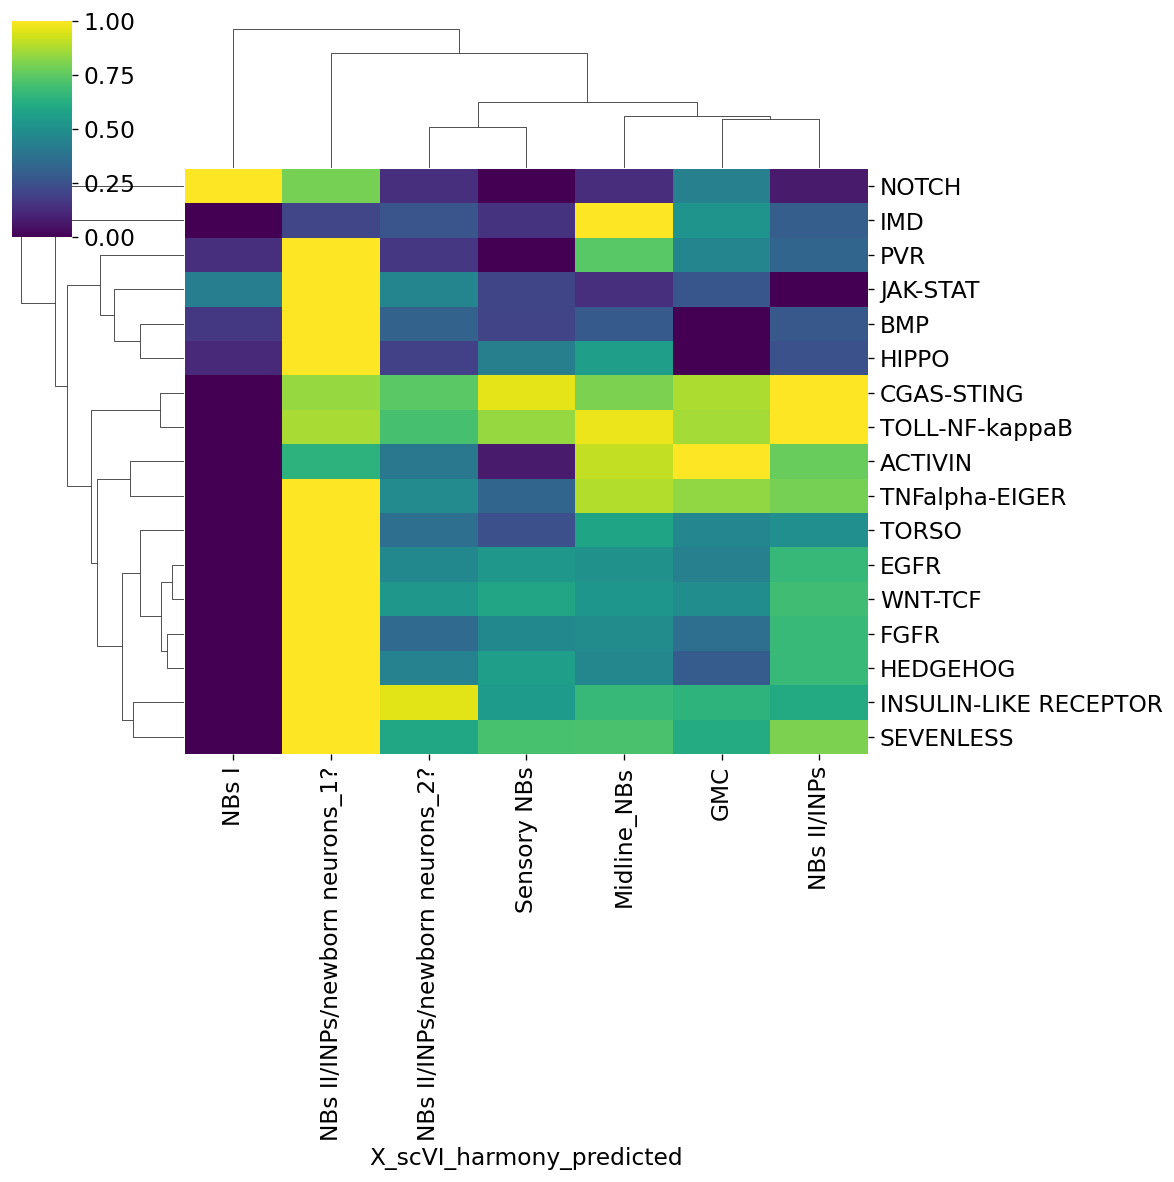

In [ ]:
pathways = (
    df.groupby("pathway")["SYMBOL"]
      .apply(lambda x: list(set(x)))  # remove duplicates within pathway
      .to_dict()
)


pathways = {
    k: [g for g in v if g in adata.var_names]
    for k, v in pathways.items()
}

pathways = {k: v for k, v in pathways.items() if len(v) > 0}

#for k, v in pathways.items():
#    print(f"{k}: {len(v)} genes")

for pathway, genes in pathways.items():
    sc.tl.score_genes(
        adata,
        gene_list=genes,
        score_name=pathway
    )


pathway_cols = list(pathways.keys())

mean_scores = (
    adata.obs
    .groupby("X_scVI_harmony_predicted")[pathway_cols]
    .mean()
)

sns.clustermap(mean_scores.T, cmap="viridis", standard_scale=0, figsize=(10, 10),
) #z_score=1 
#plt.xticks(rotation=45)
#plt.tight_layout()
output_dir = 'figures'
output_file = '1_pathways_heatmap.pdf'
plt.savefig(f'{output_dir}/{output_file}', format='pdf')
plt.show()

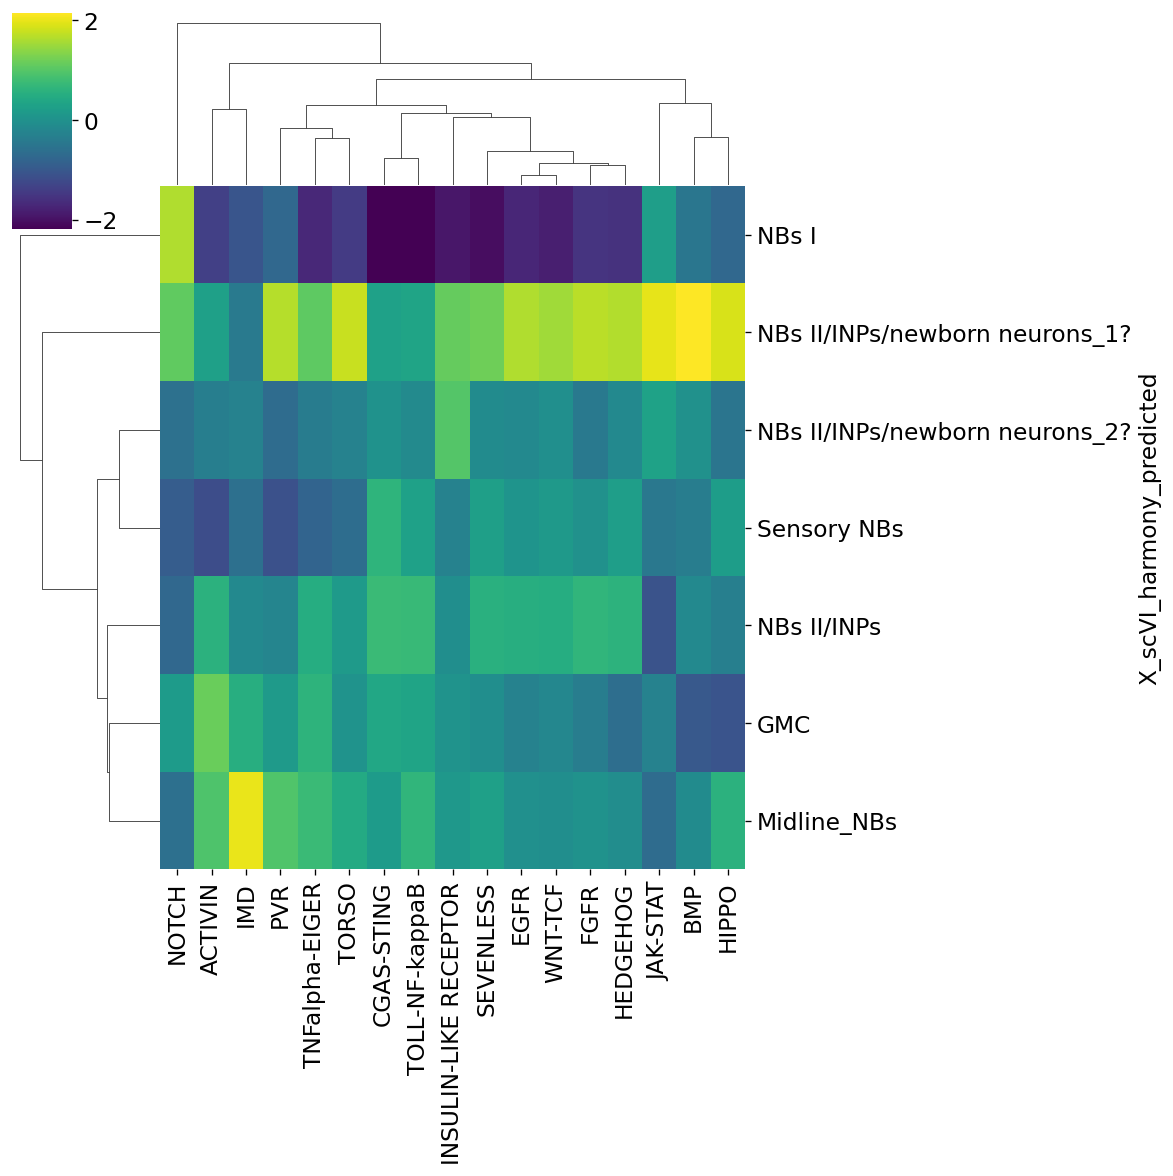

In [5]:
sns.clustermap(mean_scores, cmap="viridis", z_score=1) #z_score=1 
plt.xticks(rotation=45)
plt.show()

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_X_scVI_harmony_predicted']`


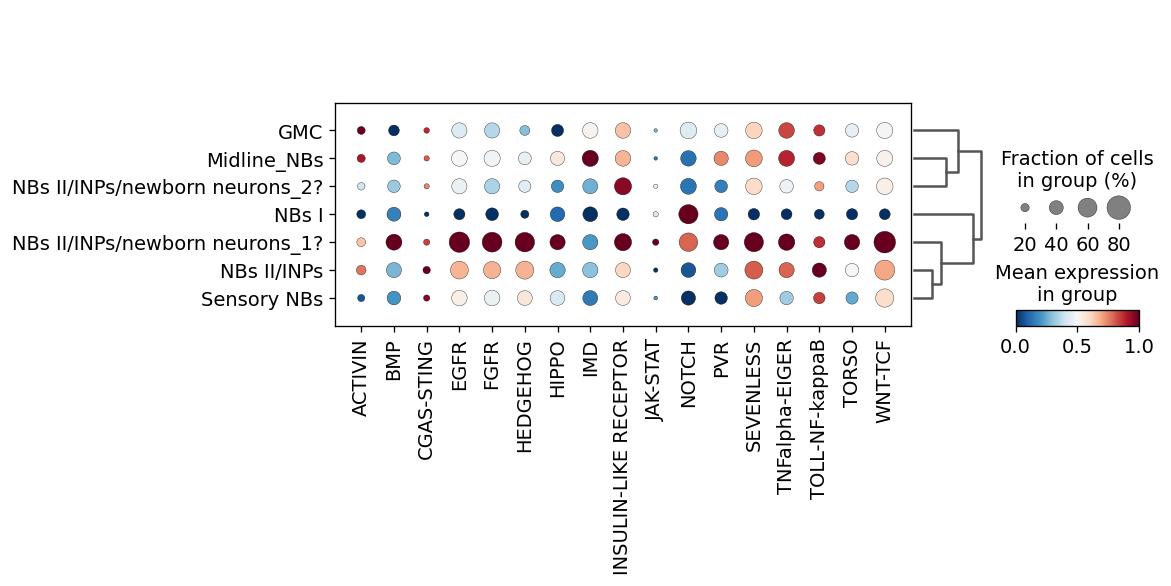

In [6]:
sc.tl.dendrogram(adata, groupby="X_scVI_harmony_predicted")

sc.pl.dotplot(
    adata,
    var_names=pathway_cols,
    groupby="X_scVI_harmony_predicted",
    standard_scale="var",
    cmap="RdBu_r",
    dendrogram=True
)
#RdBu_r
#seismic


In [7]:
adata=sc.read('../cell_annotation_brain_NBs_1_Drosophila_and_Tribolium_label_transfer.h5ad')

#Check for duplicated genes
dup_genes = df[df.duplicated("SYMBOL", keep=False)]
summary = dup_genes.groupby("SYMBOL")["pathway"].apply(list)
#keep only non duplicated genes
df_unique_1 = df[~df.duplicated(subset="SYMBOL", keep=False)]
df_unique_1['pathway'].value_counts()

pathway
INSULIN-LIKE RECEPTOR    17
PVR                      13
IMD                      12
TOLL-NF-kappaB           12
WNT-TCF                  11
NOTCH                    11
TORSO                     9
BMP                       8
FGFR                      8
JAK-STAT                  7
EGFR                      7
HEDGEHOG                  7
TNFalpha-EIGER            6
HIPPO                     6
ACTIVIN                   5
CGAS-STING                4
SEVENLESS                 3
Name: count, dtype: int64

In [8]:
df=df_unique_1
# create mapping: SYMBOL -> pathway
pathway_map = df.set_index("SYMBOL")["pathway"]
pathway_map

SYMBOL
ben                  IMD
Jra                  IMD
kay                  IMD
eff                  IMD
imd                  IMD
                 ...    
Sarm            JAK-STAT
Sting         CGAS-STING
cGlr1         CGAS-STING
cGlr2         CGAS-STING
IKKepsilon    CGAS-STING
Name: pathway, Length: 146, dtype: object

In [9]:
#df=df_unique_1
pathway_map = df.set_index("SYMBOL")["pathway"]

adata.var["pathway"] = (
    adata.var.index
    .map(pathway_map)
    .fillna("None")
)

In [10]:
adata.var['pathway'].value_counts()

pathway
None                     4683
IMD                        10
INSULIN-LIKE RECEPTOR       9
WNT-TCF                     8
NOTCH                       7
BMP                         6
HIPPO                       6
PVR                         6
TNFalpha-EIGER              5
EGFR                        5
HEDGEHOG                    5
TORSO                       5
FGFR                        4
TOLL-NF-kappaB              3
JAK-STAT                    2
ACTIVIN                     2
Name: count, dtype: int64

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_X_scVI_harmony_predicted']`


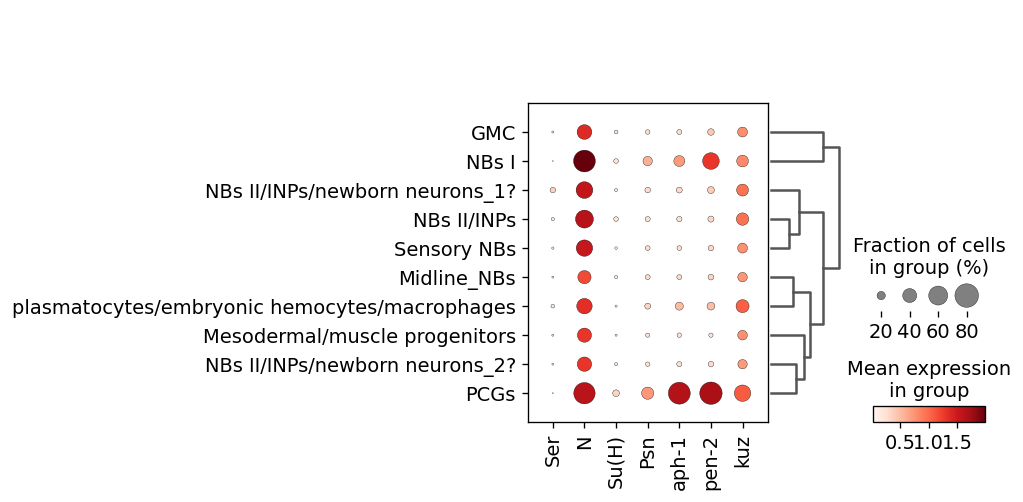

In [11]:
sc.tl.dendrogram(adata, groupby="X_scVI_harmony_predicted")

imd_genes = adata.var_names[adata.var["pathway"] == "NOTCH"]

sc.pl.dotplot(adata, imd_genes, groupby="X_scVI_harmony_predicted", dendrogram=True)  # if you have cell types

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_X_scVI_harmony_predicted']`


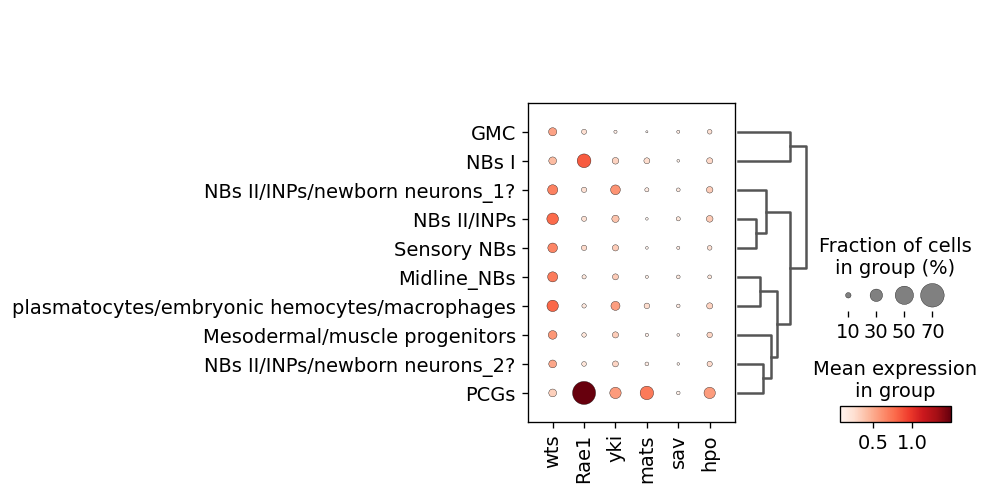

In [12]:
sc.tl.dendrogram(adata, groupby="X_scVI_harmony_predicted")

imd_genes = adata.var_names[adata.var["pathway"] == "HIPPO"]

sc.pl.dotplot(adata, imd_genes, groupby="X_scVI_harmony_predicted", dendrogram=True)  # if you have cell types

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_X_scVI_harmony_predicted']`
categories: GMC, Mesodermal/muscle progenitors, Midline_NBs, etc.
var_group_labels: ACTIVIN, BMP, EGFR, etc.


/tmp/ipykernel_109098/542565225.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("pathway")
/tmp/ipykernel_109098/542565225.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.index.tolist())


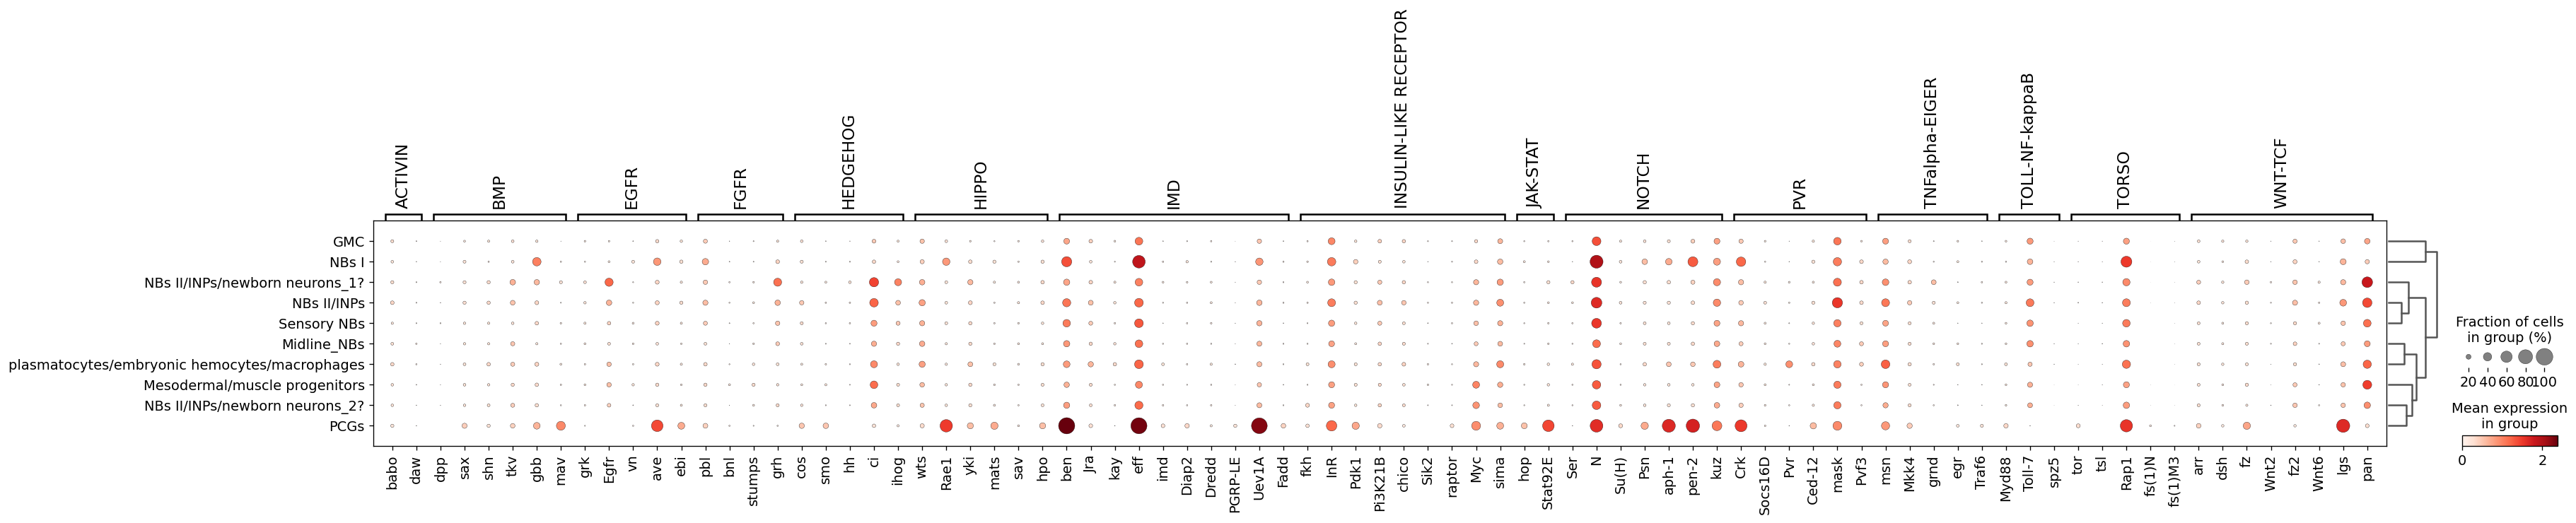

In [13]:
gene_dict = (
    adata.var
    .groupby("pathway")
    .apply(lambda x: x.index.tolist())
    .to_dict()
)

sc.tl.dendrogram(adata, groupby="X_scVI_harmony_predicted")
# remove unannotated genes
gene_dict.pop("None", None)
sc.pl.dotplot(
    adata,
    gene_dict,
    groupby="X_scVI_harmony_predicted", dendrogram=True, 
)

categories: GMC, Mesodermal/muscle progenitors, Midline_NBs, etc.
var_group_labels: ACTIVIN, BMP, EGFR, etc.


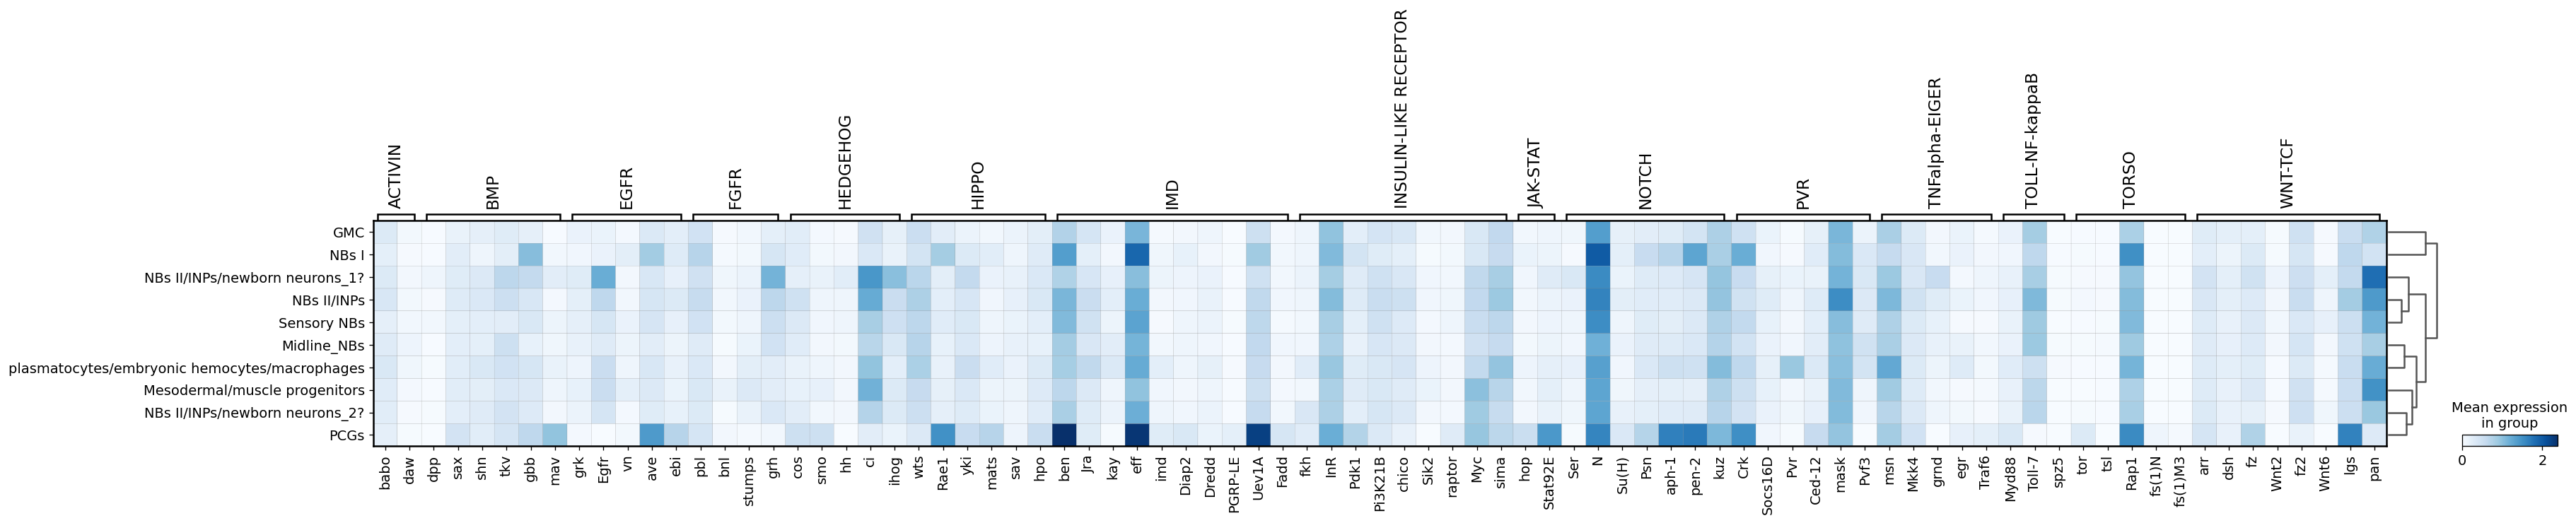

In [14]:
sc.pl.matrixplot(
    adata,
    gene_dict,
    groupby="X_scVI_harmony_predicted", dendrogram=True,
    cmap="Blues", save='1_genes_expression in pathways'
)
